Importation et téléchargement des biliothèques necssaires

In [64]:
!pip install umap-learn


In [ ]:
!pip install hdbscan


In [144]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)



In [67]:


data = pd.read_csv(r"C:\Users\dell\Downloads\marketing_campaign.csv", sep="\t")

df = data.copy()
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Compréhension des données

In [68]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [69]:
df.shape

(2240, 29)

In [70]:
print("\nColonnes :")
print(df.columns)


Colonnes :
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [71]:
print("\nTypes des variables :")
df.dtypes


Types des variables :


ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [72]:
print("\nValeurs manquantes :")
df.isnull().sum()


Valeurs manquantes :


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [73]:
print("\nNombre de doublons :")
print(df.duplicated().sum())


Nombre de doublons :
0


In [74]:
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [75]:
df = df.drop('ID', axis=1)

In [76]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [77]:
df['Education'].value_counts(normalize=True)

Education
Graduation    0.503125
PhD           0.216964
Master        0.165179
2n Cycle      0.090625
Basic         0.024107
Name: proportion, dtype: float64

In [78]:
df['Education'].replace("2n Cycle", "Master", inplace=True)
df['Education'].value_counts()

C:\Users\dell\AppData\Local\Temp\ipykernel_4456\2805097419.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education'].replace("2n Cycle", "Master", inplace=True)


Education
Graduation    1127
Master         573
PhD            486
Basic           54
Name: count, dtype: int64

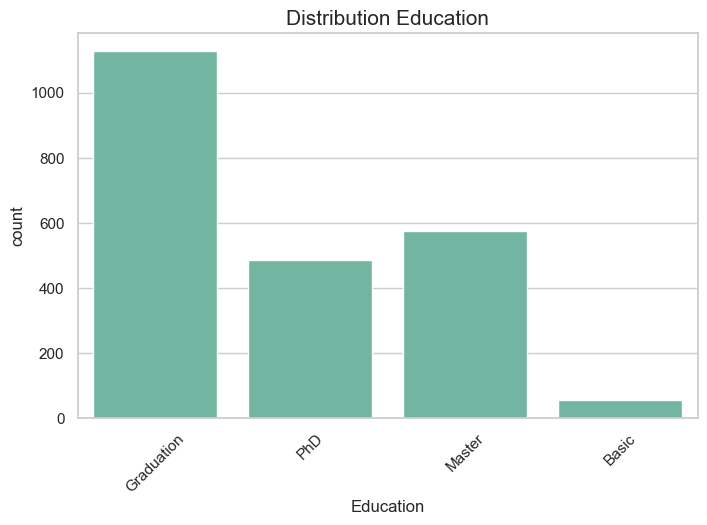

In [79]:
plt.figure(figsize=(8,5))

sns.countplot(x='Education', data=df)

plt.title('Distribution Education')

plt.xticks(rotation=45)

plt.show()

In [80]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [81]:
df['Marital_Status'].replace("Absurd", "Single", inplace=True)
df['Marital_Status'].replace("YOLO", "Single", inplace=True)
df['Marital_Status'].replace("Alone", "Single", inplace=True)
df['Marital_Status'].value_counts()

C:\Users\dell\AppData\Local\Temp\ipykernel_4456\1198018701.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marital_Status'].replace("Absurd", "Single", inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_4456\1198018701.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

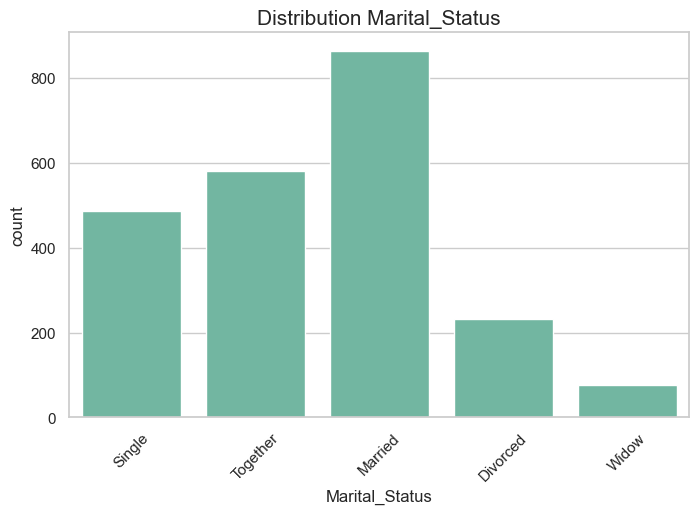

In [82]:
plt.figure(figsize=(8,5))

sns.countplot(x='Marital_Status', data=df)

plt.title('Distribution Marital_Status')

plt.xticks(rotation=45)

plt.show()

In [83]:
df['Income'].isnull().sum()

np.int64(24)

In [84]:
df['Income'].fillna(df['Income'].mean(), inplace=True)
df['Income'].isnull().sum()

C:\Users\dell\AppData\Local\Temp\ipykernel_4456\1531084915.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].mean(), inplace=True)


np.int64(0)

In [85]:
df['Income'].describe()

count      2240.000000
mean      52247.251354
std       25037.797168
min        1730.000000
25%       35538.750000
50%       51741.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

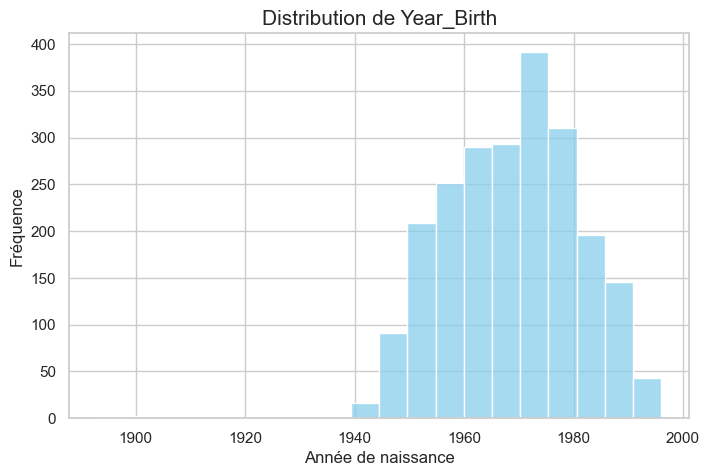

In [86]:
plt.figure(figsize=(8,5))

sns.histplot(df['Year_Birth'], bins=20, color='skyblue')

plt.title('Distribution de Year_Birth')
plt.xlabel('Année de naissance')
plt.ylabel('Fréquence')

plt.show()

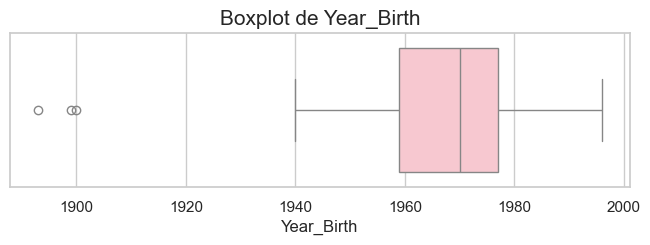

In [87]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Year_Birth'], color='pink')

plt.title('Boxplot de Year_Birth')

plt.show()

In [88]:
df[df['Year_Birth'] < 1930]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
192,1900,Master,Divorced,36640.0,1,0,26-09-2013,99,15,6,...,5,0,0,0,0,0,1,3,11,0
239,1893,Master,Single,60182.0,0,1,17-05-2014,23,8,0,...,4,0,0,0,0,0,0,3,11,0
339,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,144,...,1,0,0,1,0,0,0,3,11,0


In [89]:
print("\n supprimmer les valeurs abbérantes")
df = df[df['Year_Birth'] >= 1930]


 supprimmer les valeurs abbérantes


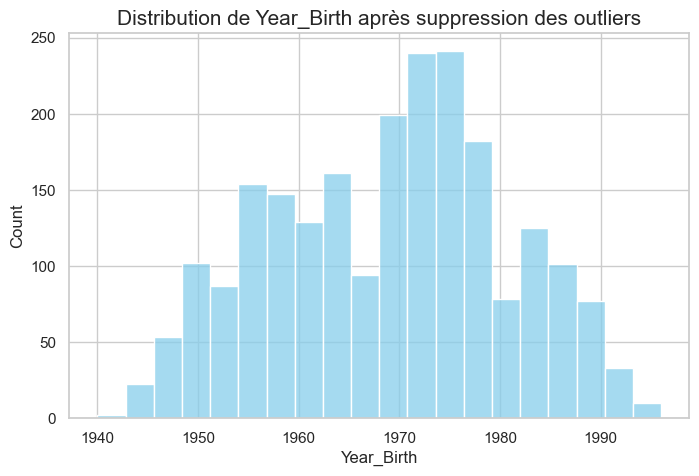

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(df['Year_Birth'], bins=20, color='skyblue')

plt.title('Distribution de Year_Birth après suppression des outliers')

plt.show()

Visualisation de Income

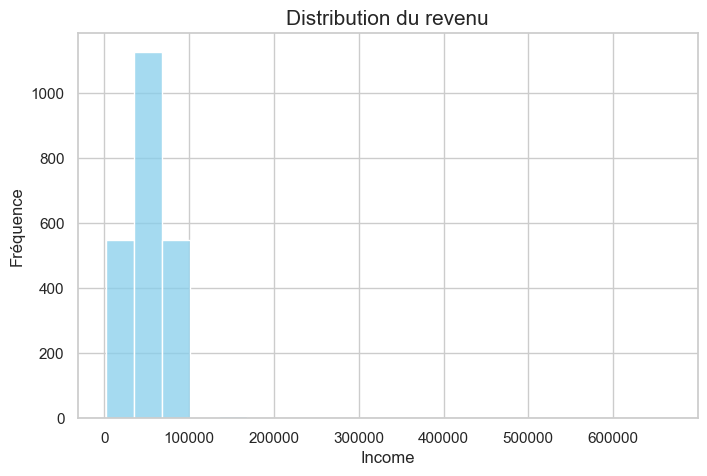

In [91]:
#Visualisation de Income
plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=20, color='skyblue')

plt.title('Distribution du revenu')

plt.xlabel('Income')
plt.ylabel('Fréquence')

plt.show()

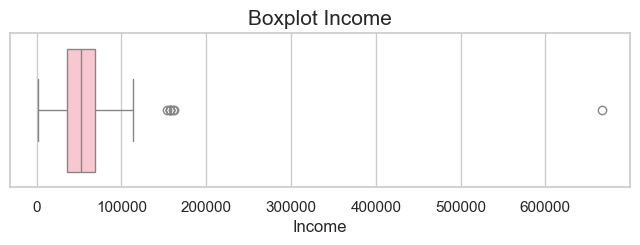

In [92]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Income'], color='pink')

plt.title('Boxplot Income')

plt.show()

In [93]:
df[df['Income'] > 200000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,14,...,6,0,0,0,0,0,0,3,11,0


In [94]:
df['Income'].quantile(0.99)

np.float64(94440.31999999999)

In [95]:
print("\n supprimmer les valeurs abbérantes de Income")
df = df[df['Income'] < 100000].reset_index(drop=True)


 supprimmer les valeurs abbérantes de Income


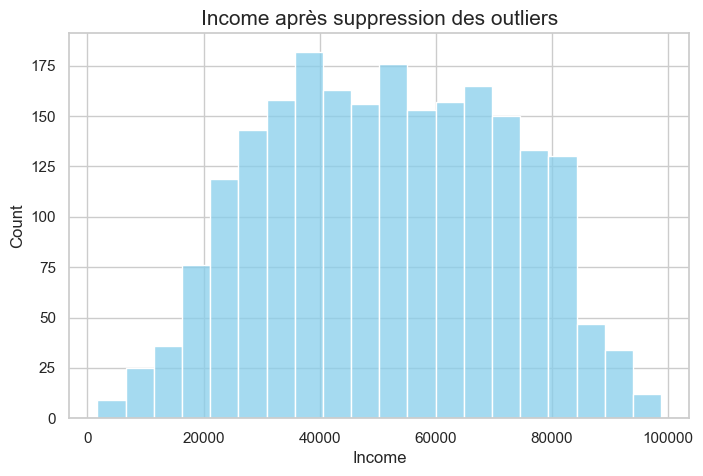

In [96]:
plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=20, color='skyblue')

plt.title('Income après suppression des outliers')

plt.show()

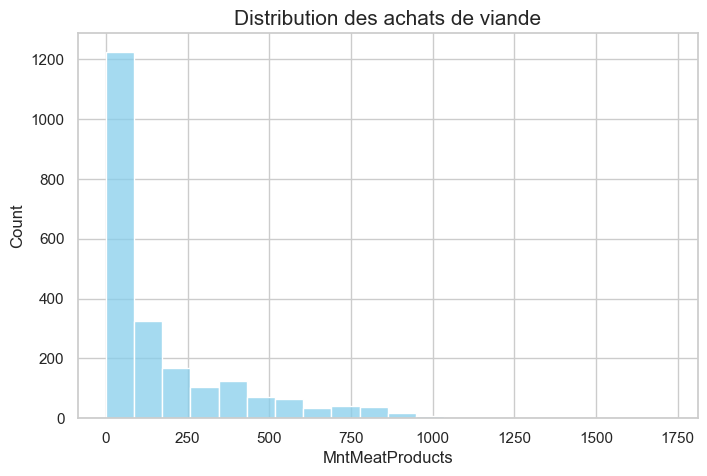

In [97]:
plt.figure(figsize=(8,5))

sns.histplot(df['MntMeatProducts'], bins=20, color='skyblue')

plt.title('Distribution des achats de viande')

plt.show()

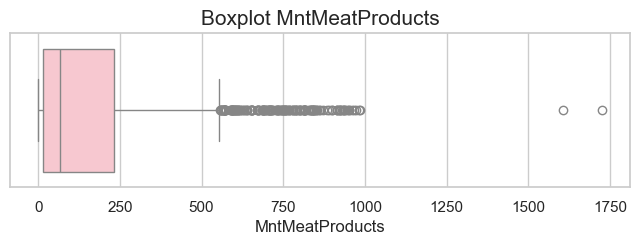

In [98]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['MntMeatProducts'], color='pink')

plt.title('Boxplot MntMeatProducts')

plt.show()

In [99]:
df['MntMeatProducts'].quantile(0.99)

np.float64(898.77)

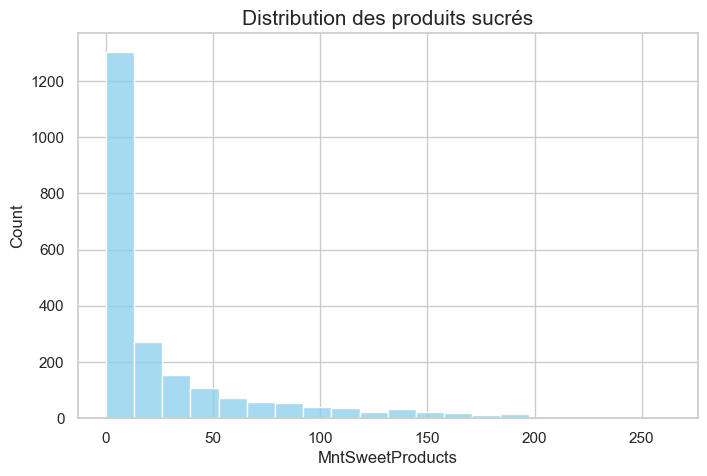

In [100]:
#Visualisation MntSweetProducts
plt.figure(figsize=(8,5))

sns.histplot(df['MntSweetProducts'], bins=20, color='skyblue')

plt.title('Distribution des produits sucrés')

plt.show()

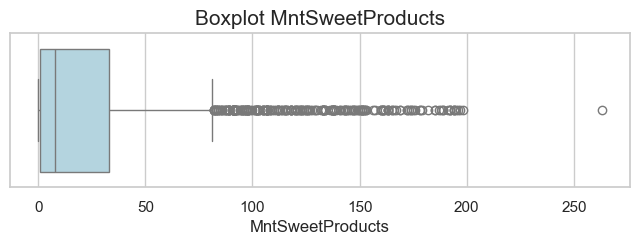

In [101]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['MntSweetProducts'], color='lightblue')

plt.title('Boxplot MntSweetProducts')

plt.show()

In [102]:
df['MntSweetProducts'].quantile(0.99)

np.float64(175.76999999999998)

In [103]:
df[df['MntSweetProducts'] > 200]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
27,1986,Graduation,Single,52247.251354,1,0,20-02-2013,19,5,1,...,1,0,0,0,0,0,0,3,11,0


In [104]:
for col in df.columns:
    
    if df[col].nunique() == 1:
        
        print(col, "est une colonne constante")

Z_CostContact est une colonne constante
Z_Revenue est une colonne constante


In [105]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'], errors='ignore')


In [106]:
df['Age'] = 2016 - df['Year_Birth']
print(df[['Year_Birth', 'Age']].head())


   Year_Birth  Age
0        1957   59
1        1954   62
2        1965   51
3        1984   32
4        1981   35


In [107]:
df['Children'] = df['Kidhome'] + df['Teenhome']
print(df[['Kidhome', 'Teenhome', 'Children']].head())

   Kidhome  Teenhome  Children
0        0         0         0
1        1         1         2
2        0         0         0
3        1         0         1
4        1         0         1


In [108]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married': 'Relation',
    'Together': 'Relation',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Alone': 'Single'
})
print(df['Marital_Status'].value_counts())

Marital_Status
Relation    1434
Single       790
Name: count, dtype: int64


In [109]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Single': 1,
    'Relation': 2
})

df['Family_Size'] = df['Children'] + df['Marital_Status']

print(df[['Children', 'Marital_Status', 'Family_Size']].head())

   Children  Marital_Status  Family_Size
0         0               1            1
1         2               1            3
2         0               2            2
3         1               2            3
4         1               2            3


C:\Users\dell\AppData\Local\Temp\ipykernel_4456\3612568599.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Marital_Status'] = df['Marital_Status'].replace({


In [110]:
df['Total_Spent'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

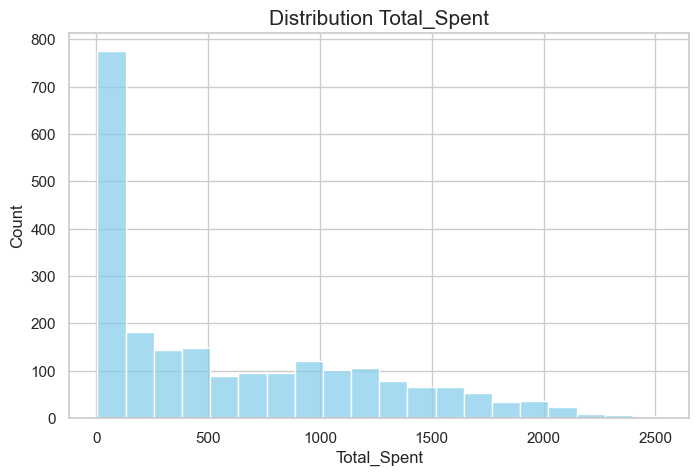

In [111]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total_Spent'], bins=20, color='skyblue')

plt.title('Distribution Total_Spent')

plt.show()

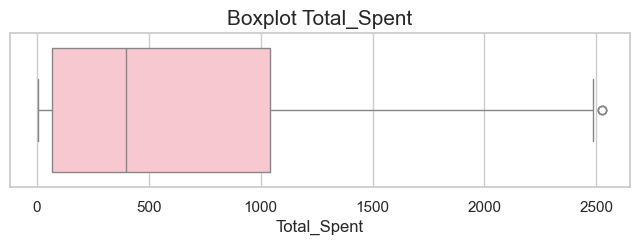

In [112]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Total_Spent'], color='pink')

plt.title('Boxplot Total_Spent')

plt.show()

In [113]:
df['Num_Total_Purchases'] = (
    df['NumDealsPurchases'] +
    df['NumStorePurchases'] +
    df['NumWebPurchases'] +
    df['NumCatalogPurchases']
)
print(df['Num_Total_Purchases'].head())

0    25
1     6
2    21
3     8
4    19
Name: Num_Total_Purchases, dtype: int64


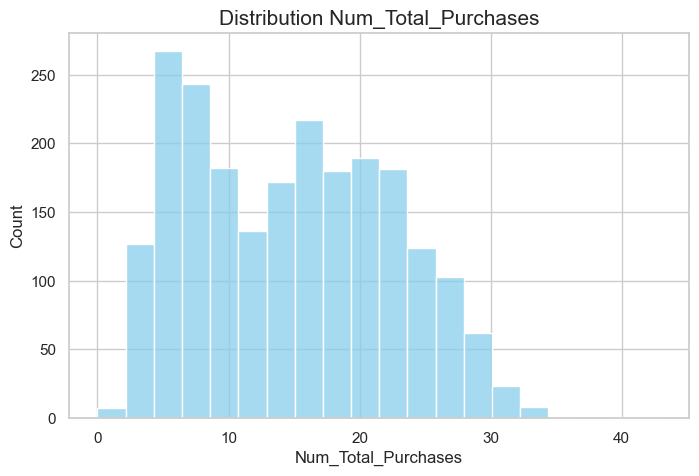

In [114]:
plt.figure(figsize=(8,5))

sns.histplot(df['Num_Total_Purchases'], bins=20, color='skyblue')

plt.title('Distribution Num_Total_Purchases')

plt.show()

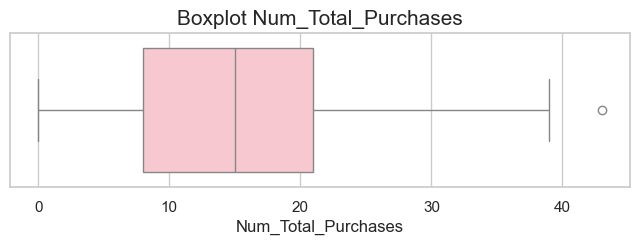

In [115]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Num_Total_Purchases'], color='pink')

plt.title('Boxplot Num_Total_Purchases')

plt.show()

In [116]:
df['Spent_Per_Purchase'] = np.where(
    df['Num_Total_Purchases'] > 0,
    df['Total_Spent'] / df['Num_Total_Purchases'],
    0
)

print(df['Spent_Per_Purchase'].head())

0    64.680000
1     4.500000
2    36.952381
3     6.625000
4    22.210526
Name: Spent_Per_Purchase, dtype: float64


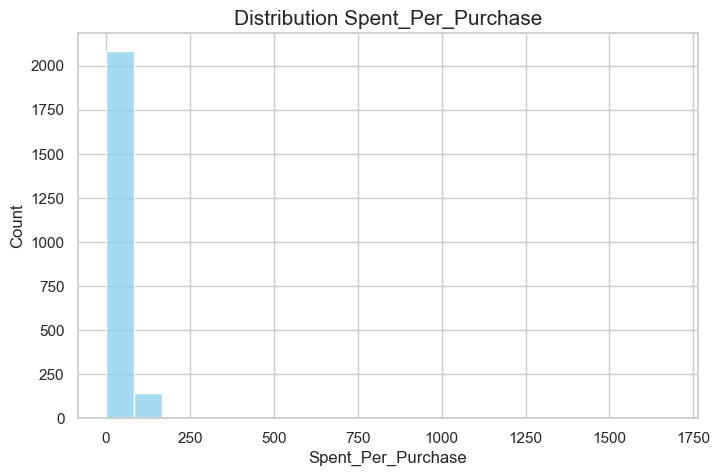

In [117]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spent_Per_Purchase'], bins=20, color='skyblue')

plt.title('Distribution Spent_Per_Purchase')

plt.show()

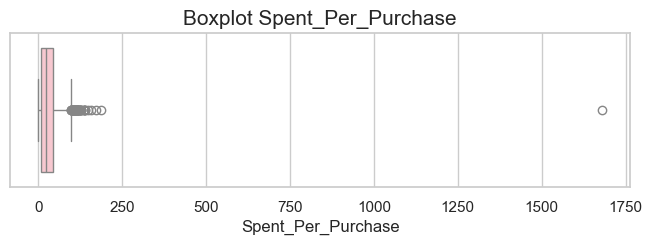

In [118]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Spent_Per_Purchase'], color='pink')

plt.title('Boxplot Spent_Per_Purchase')

plt.show()

In [119]:
df = df[df['Spent_Per_Purchase'] < 250]

df = df.reset_index(drop=True)

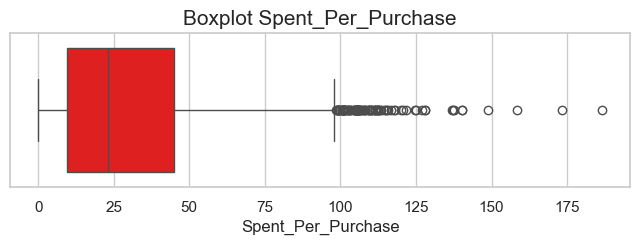

In [120]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Spent_Per_Purchase'], color='red')

plt.title('Boxplot Spent_Per_Purchase')

plt.show()

In [121]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y',
    errors='coerce'
)

print(df['Dt_Customer'].head())

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


In [122]:
reference_date = pd.to_datetime('2016-01-01')

df['Days_Since_Enrolled'] = (
    reference_date - df['Dt_Customer']
).dt.days

# Remplacer les valeurs manquantes éventuelles par la médiane
df['Days_Since_Enrolled'] = df['Days_Since_Enrolled'].fillna(
    df['Days_Since_Enrolled'].median()
)

print(df['Days_Since_Enrolled'].head())

0    1214
1     664
2     863
3     690
4     712
Name: Days_Since_Enrolled, dtype: int64


In [123]:
# Style général
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [124]:
df['Total_Accepted_Campaigns'] = (
    df['AcceptedCmp1'] +
    df['AcceptedCmp2'] +
    df['AcceptedCmp3'] +
    df['AcceptedCmp4'] +
    df['AcceptedCmp5'] +
    df['Response']
)

print(df['Total_Accepted_Campaigns'].head())

0    1
1    0
2    0
3    0
4    0
Name: Total_Accepted_Campaigns, dtype: int64


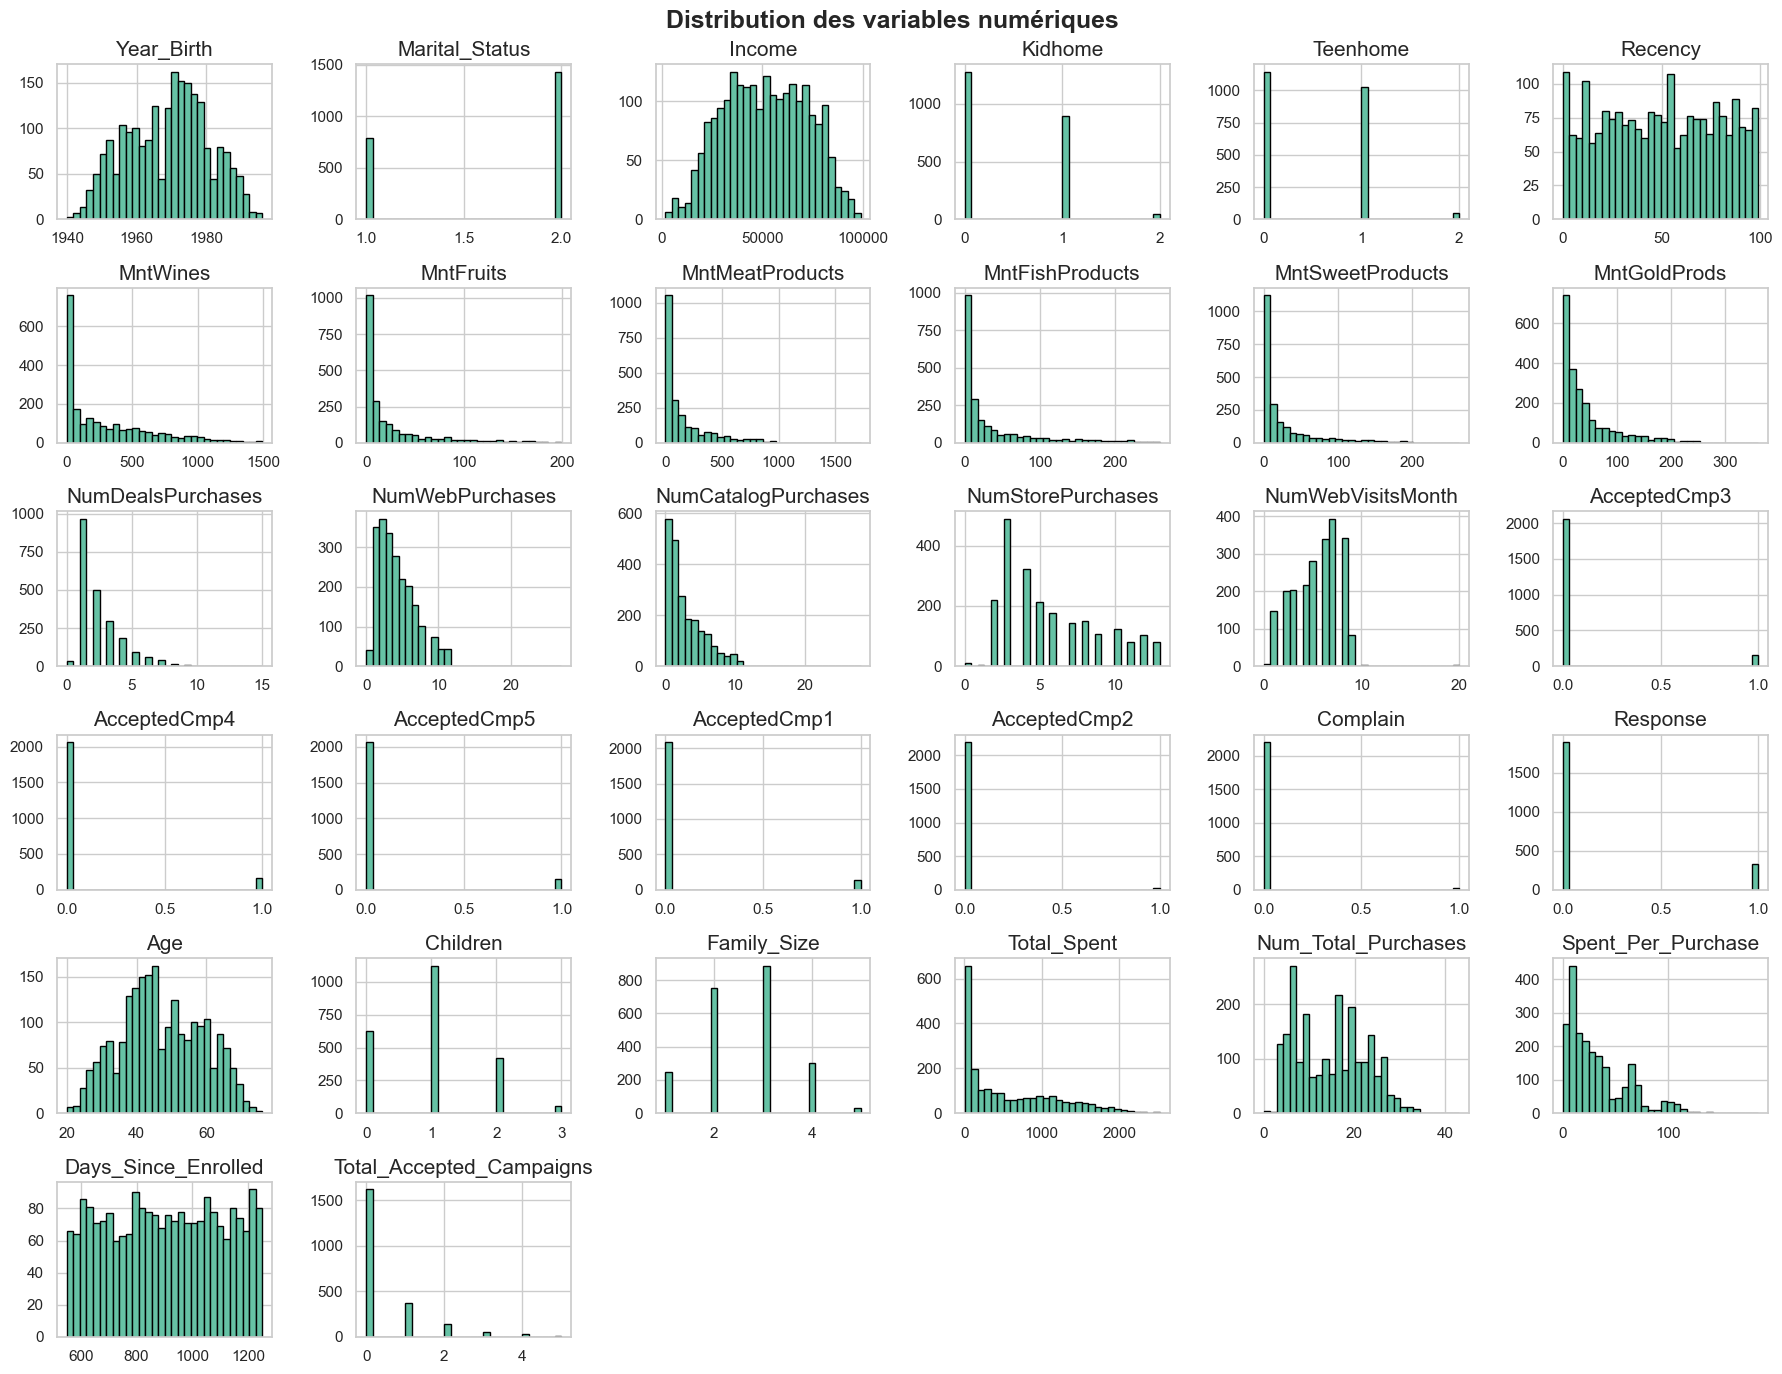

In [129]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(
    figsize=(18, 14),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distribution des variables numériques",
    fontsize=18,
    fontweight="bold"
)
plt.savefig("Distribution_des_variables_numeriques.png", dpi=300)

plt.tight_layout()
plt.show()

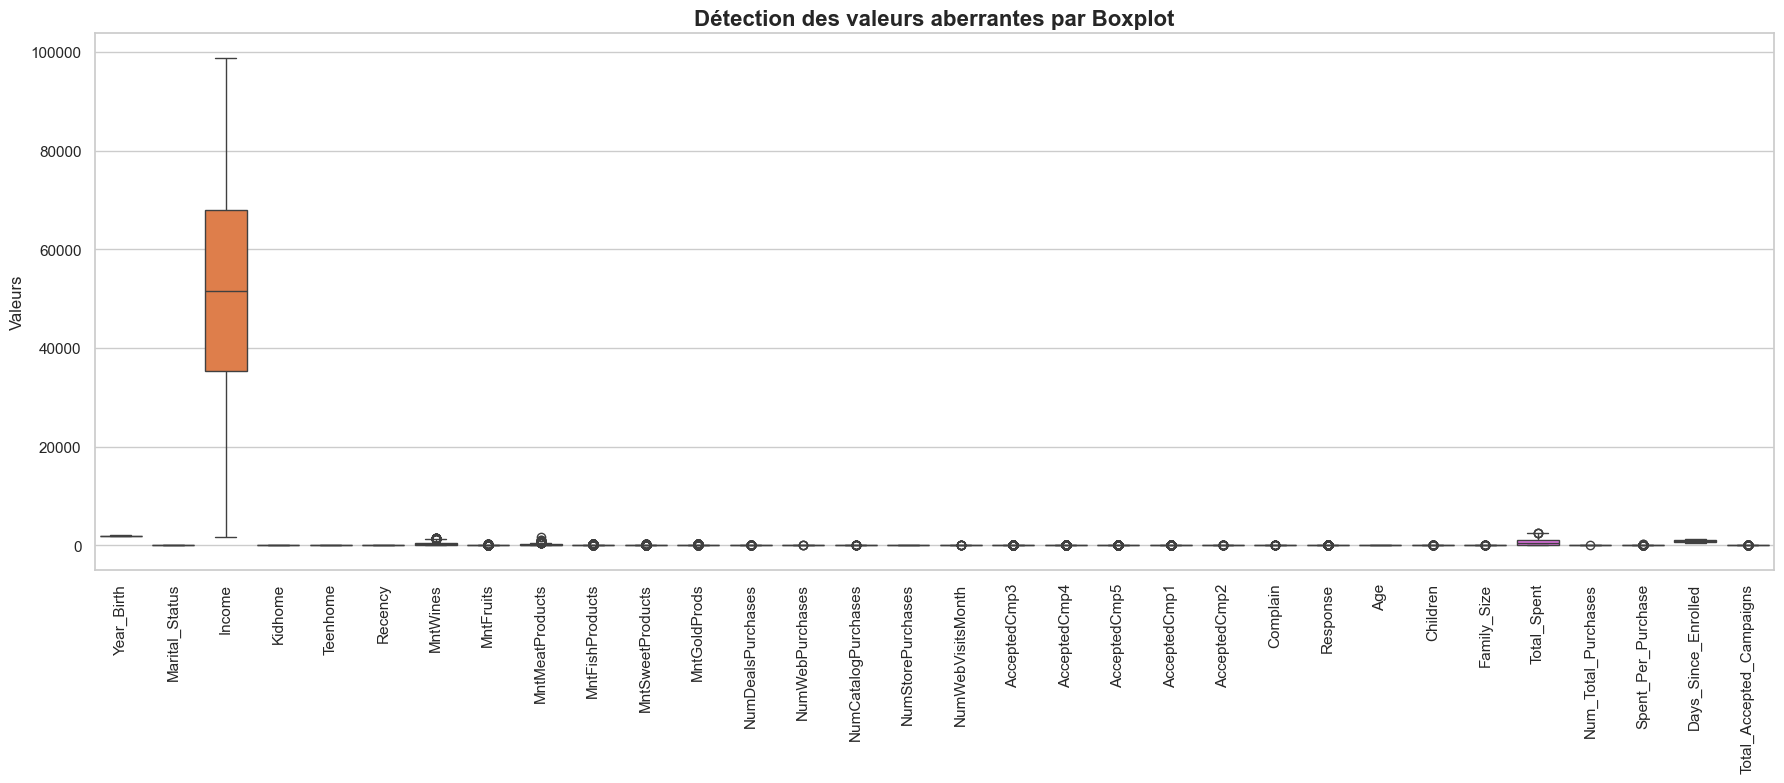

In [ ]:
plt.figure(figsize=(18, 8))

sns.boxplot(data=df[numeric_cols])

plt.title(
    "Détection des valeurs aberrantes par Boxplot",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=90)
plt.savefig("Détection_des_valeurs_aberrantes_par_Boxplot.png", dpi=300)
plt.ylabel("Valeurs")
plt.tight_layout()
plt.show()

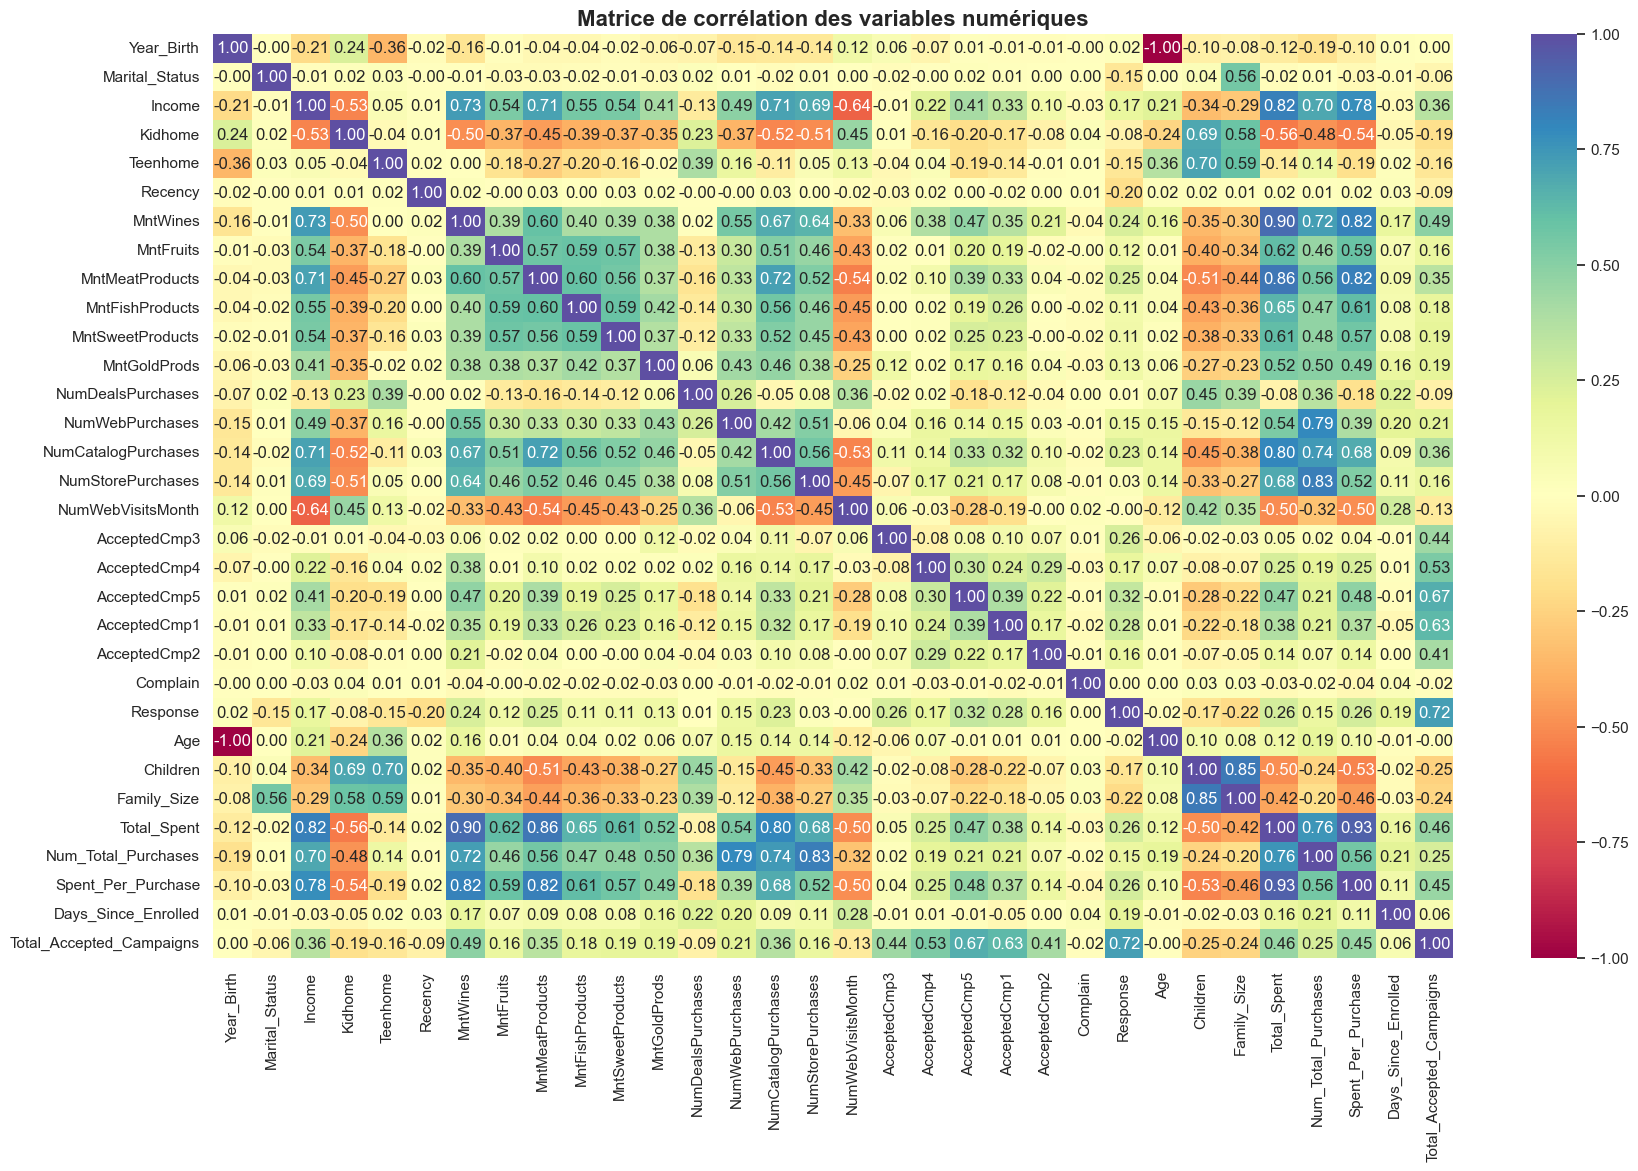

In [130]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (20, 12))

sns.heatmap(
    df[numeric_cols].corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)
plt.title(
    "Matrice de corrélation des variables numériques",
    fontsize=16,
    fontweight="bold"
)
plt.savefig("Correlation_des_variables_numeriques.png", dpi=300)
plt.show()

 Scatter plot

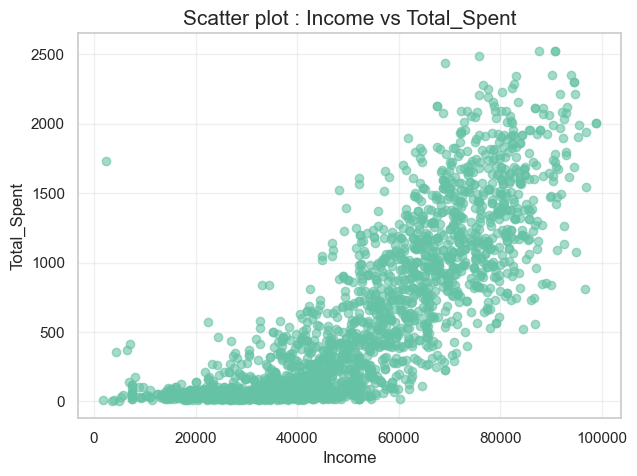

In [131]:
if "Income" in df.columns and "Total_Spent" in df.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(df["Income"], df["Total_Spent"], alpha=0.6)
    plt.xlabel("Income")
    plt.ylabel("Total_Spent")
    plt.title("Scatter plot : Income vs Total_Spent")
    plt.grid(alpha=0.3)
    plt.savefig("Scatter_plot_Income_vs_Total_Spent.png", dpi=300)
    plt.show()

Prétraitement de data



In [132]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if "Dt_Customer" in df.columns:
    df_model = df.drop(columns=["Dt_Customer"]).copy()
else:
    df_model = df.copy()

df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

# Garder uniquement les colonnes numériques
df_numeric = df_encoded.select_dtypes(include=[np.number, "bool"]).copy()

# Convertir les booléens en entiers
bool_cols = df_numeric.select_dtypes(include=["bool"]).columns
df_numeric[bool_cols] = df_numeric[bool_cols].astype(int)

print("Dimensions après encodage :", df_numeric.shape)
display(df_numeric.head())

Dimensions après encodage : (2223, 35)


,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Children,Family_Size,Total_Spent,Num_Total_Purchases,Spent_Per_Purchase,Days_Since_Enrolled,Total_Accepted_Campaigns,Education_Graduation,Education_Master,Education_PhD
0,1957,1,58138.0,0,0,58,635,88,546,172,...,0,1,1617,25,64.680000,1214,1,1,0,0
1,1954,1,46344.0,1,1,38,11,1,6,2,...,2,3,27,6,4.500000,664,0,1,0,0
2,1965,2,71613.0,0,0,26,426,49,127,111,...,0,2,776,21,36.952381,863,0,1,0,0
3,1984,2,26646.0,1,0,26,11,4,20,10,...,1,3,53,8,6.625000,690,0,1,0,0
4,1981,2,58293.0,1,0,94,173,43,118,46,...,1,3,422,19,22.210526,712,0,0,0,1


In [133]:
# Imputation des valeurs manquantes par la médiane
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(df_numeric)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

feature_names = df_numeric.columns

print("Données après imputation :", X_imputed.shape)
print("Données après standardisation :", X_scaled.shape)

Données après imputation : (2223, 35)
Données après standardisation : (2223, 35)


 Détection des valeurs aberrantes



In [134]:
# Détection des outliers
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso.fit_predict(X_scaled)

n_outliers = np.sum(outlier_labels == -1)
print("Nombre d'outliers détectés :", n_outliers)

# Données nettoyées
X_clean = X_scaled[outlier_labels == 1]

print("Données avant nettoyage :", X_scaled.shape)
print("Données après suppression des outliers :", X_clean.shape)

Nombre d'outliers détectés : 112
Données avant nettoyage : (2223, 35)
Données après suppression des outliers : (2111, 35)


 Réduction de dimension 

Variance expliquée par PC1 et PC2 :
[0.2794 0.1012]


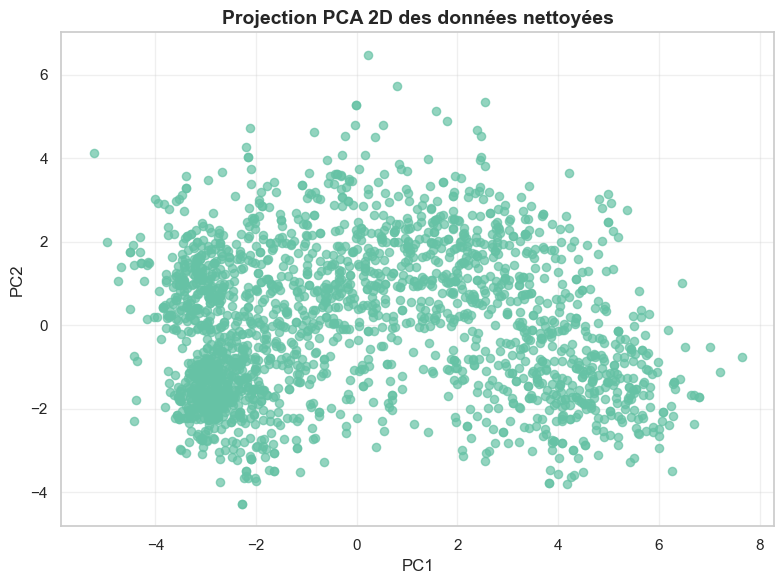

In [135]:
# PCA 
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_clean)

print("Variance expliquée par PC1 et PC2 :")
print(np.round(pca_2d.explained_variance_ratio_, 4))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=35, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA 2D des données nettoyées", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.savefig("Projection_PCA_2D_des_données_nettoyées.png", dpi=300)
plt.tight_layout()
plt.show()

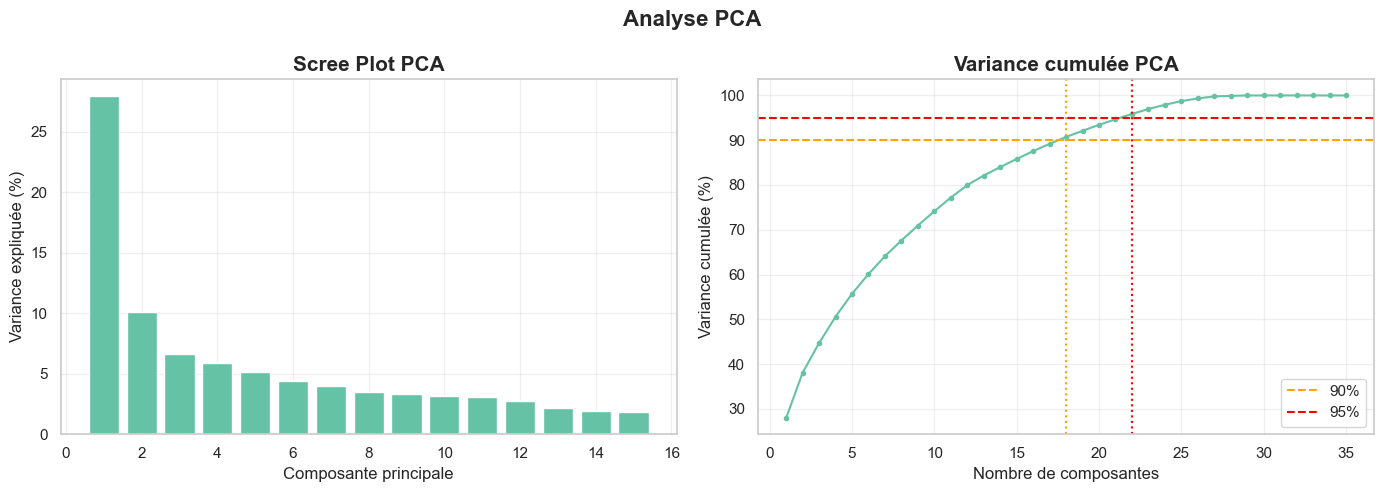

Nombre de composantes pour 90% de variance : 18
Nombre de composantes pour 95% de variance : 22


In [136]:

pca_full = PCA(random_state=42)
pca_full.fit(X_clean)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    range(1, min(16, len(pca_full.explained_variance_ratio_) + 1)),
    pca_full.explained_variance_ratio_[:15] * 100
)
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree Plot PCA", fontweight="bold")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=3)
axes[1].axhline(90, color="orange", linestyle="--", label="90%")
axes[1].axhline(95, color="red", linestyle="--", label="95%")
axes[1].axvline(n90, color="orange", linestyle=":")
axes[1].axvline(n95, color="red", linestyle=":")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée (%)")
axes[1].set_title("Variance cumulée PCA", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Analyse PCA", fontsize=16, fontweight="bold")
plt.savefig("Analyse_PCA.png", dpi=300)
plt.tight_layout()
plt.show()

print(f"Nombre de composantes pour 90% de variance : {n90}")
print(f"Nombre de composantes pour 95% de variance : {n95}")

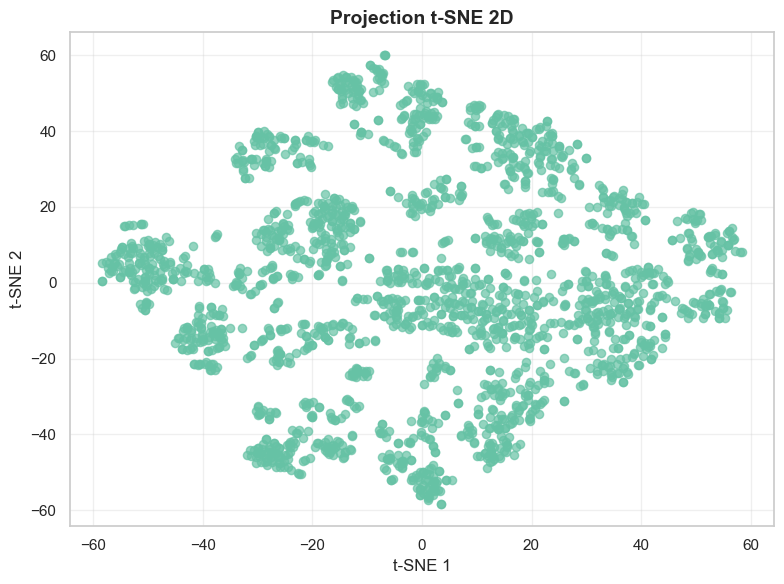

In [ ]:
# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_clean)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=35, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Projection t-SNE 2D", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

c:\Users\dell\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


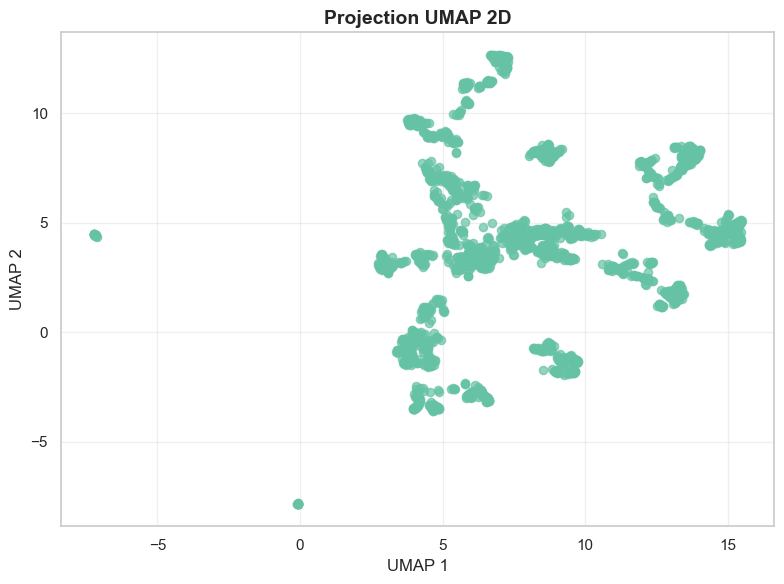

In [145]:
# UMAP 
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_clean)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=35, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP 2D", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.savefig("Projection_UMAP_2D.png", dpi=300)
plt.tight_layout()
plt.show()


 Optimisation de K-Means

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

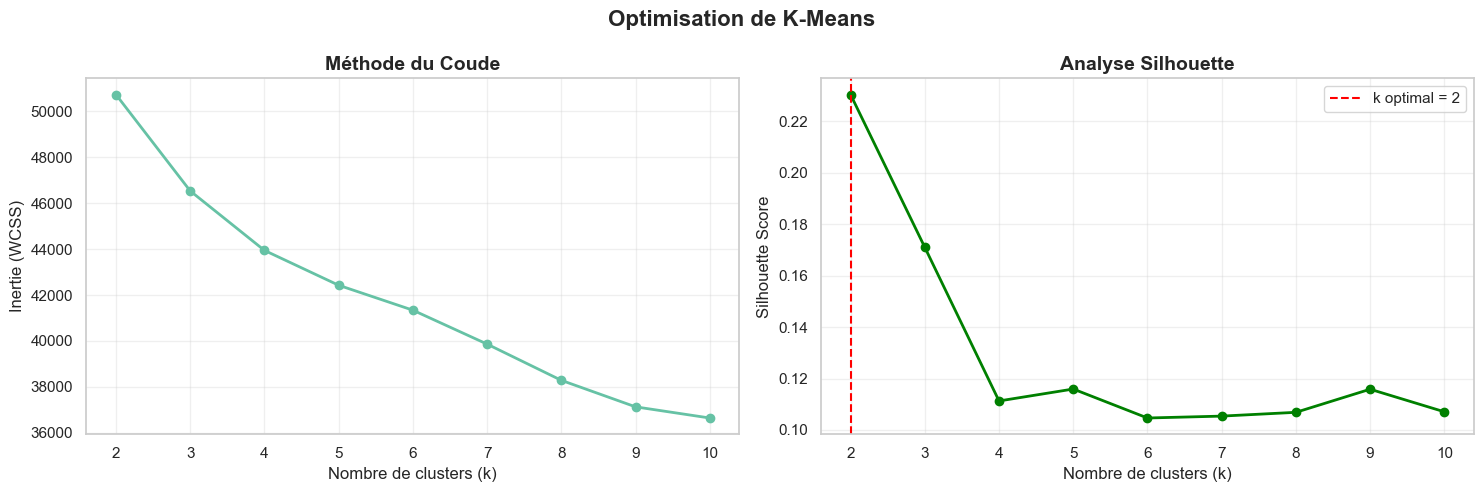

Meilleur k selon le Silhouette Score : 2


In [147]:
K_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_clean)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clean, labels))

best_k = list(K_range)[np.argmax(silhouette_scores)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(K_range), inertias, marker="o", linewidth=2)
axes[0].set_title("Méthode du Coude", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inertie (WCSS)")
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouette_scores, marker="o", linewidth=2, color="green")
axes[1].axvline(best_k, color="red", linestyle="--", label=f"k optimal = {best_k}")
axes[1].set_title("Analyse Silhouette", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Optimisation de K-Means", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Optimisation_K_Means.png", dpi=300)
plt.show()

print(f"Meilleur k selon le Silhouette Score : {best_k}")

## 8. Implémentation des modèles de clustering

In [153]:
# K-Means
km_final = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=10,
    random_state=42
)
labels_kmeans = km_final.fit_predict(X_clean)

# DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
labels_dbscan = dbscan.fit_predict(X_clean)
n_noise_db = np.sum(labels_dbscan == -1)

# Agglomerative Clustering
agg_final = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)
labels_agg = agg_final.fit_predict(X_clean)

# GMM
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=42,
    n_init=5
)
labels_gmm = gmm_final.fit_predict(X_clean)
proba_gmm = gmm_final.predict_proba(X_clean)

# Spectral Clustering
spectral = SpectralClustering(
    n_clusters=best_k,
    affinity="nearest_neighbors",
    random_state=42
)
labels_spectral = spectral.fit_predict(X_clean)

# HDBSCAN 
hdb = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5
)
labels_hdbscan = hdb.fit_predict(X_clean)


cluster_results = {
    "K-Means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "Agglomerative": labels_agg,
    "GMM": labels_gmm,
    "Spectral": labels_spectral
}

if labels_hdbscan is not None:
    cluster_results["HDBSCAN"] = labels_hdbscan

print("Modèles entraînés :", list(cluster_results.keys()))
print("Bruit détecté par DBSCAN :", n_noise_db)

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Modèles entraînés : ['K-Means', 'DBSCAN', 'Agglomerative', 'GMM', 'Spectral', 'HDBSCAN']
Bruit détecté par DBSCAN : 1780


 DBSCAN avec la courbe k-distance

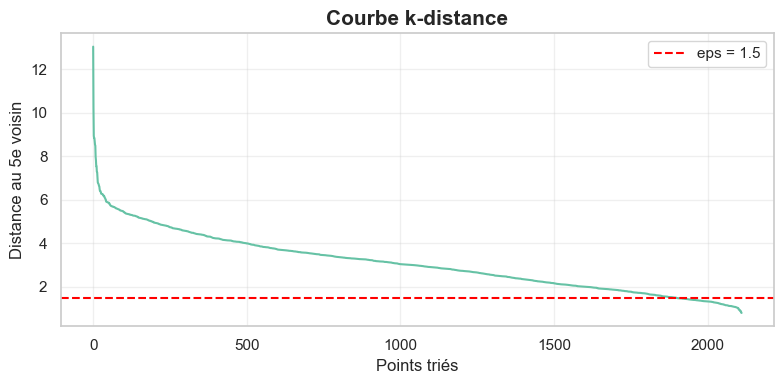

In [154]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_clean)
dists, _ = nbrs.kneighbors(X_clean)

k_dists = np.sort(dists[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dists)
plt.axhline(1.5, color="red", linestyle="--", label="eps = 1.5")
plt.xlabel("Points triés")
plt.ylabel("Distance au 5e voisin")
plt.title("Courbe k-distance", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Courbe_k_distance.png", dpi=300)
plt.show()


 Visualisation des clusters

In [155]:
def plot_clusters(coords, labels, title):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="tab10",
        s=35,
        alpha=0.75,
        edgecolors="none"
    )

    plt.xlabel("Composante 1")
    plt.ylabel("Composante 2")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("Projection_UMAP_2D.png", dpi=300)
    plt.show()

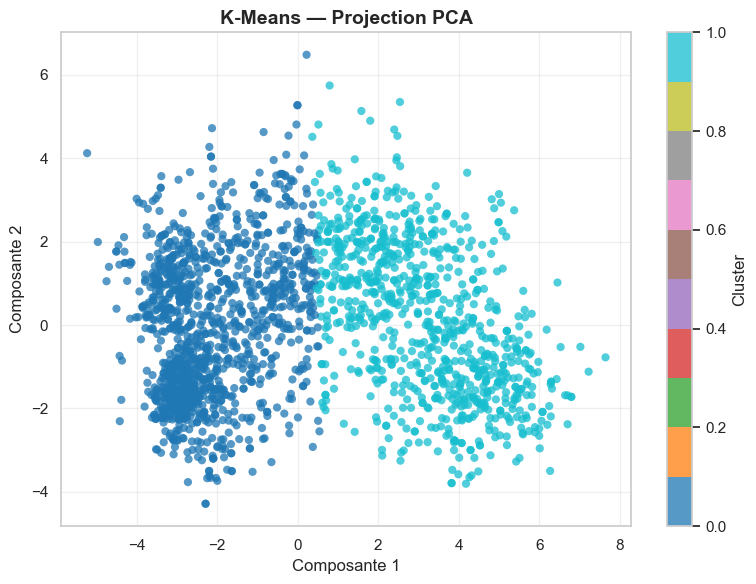

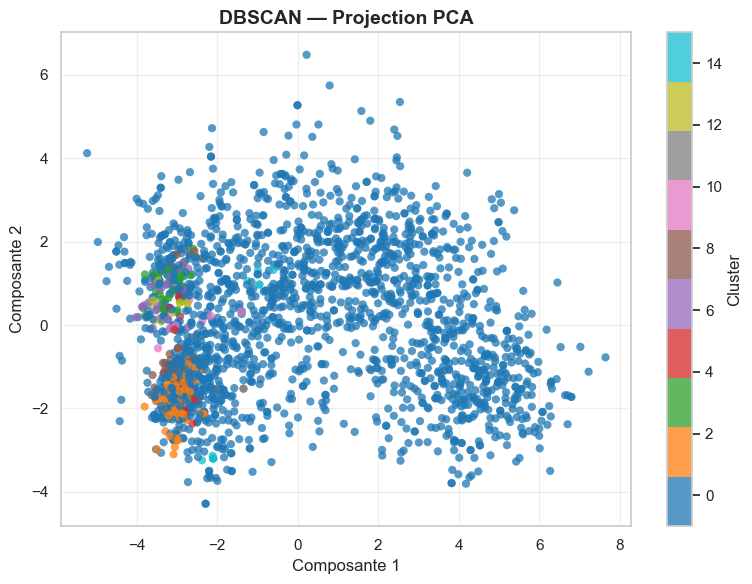

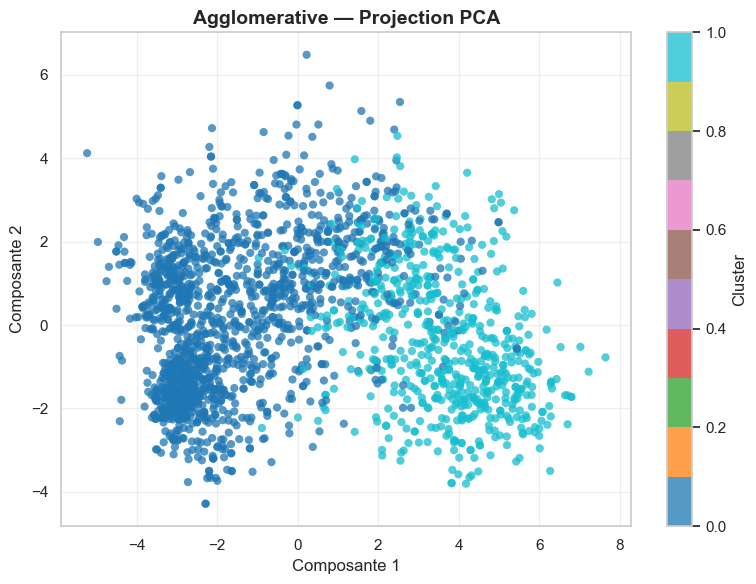

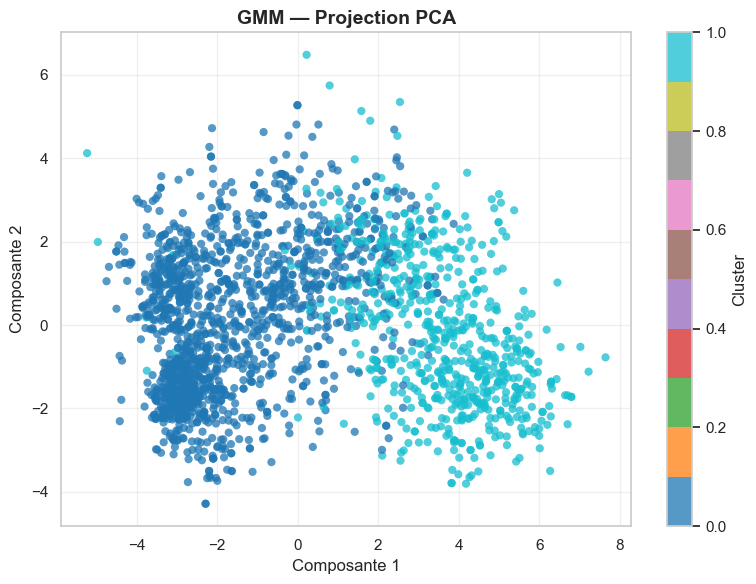

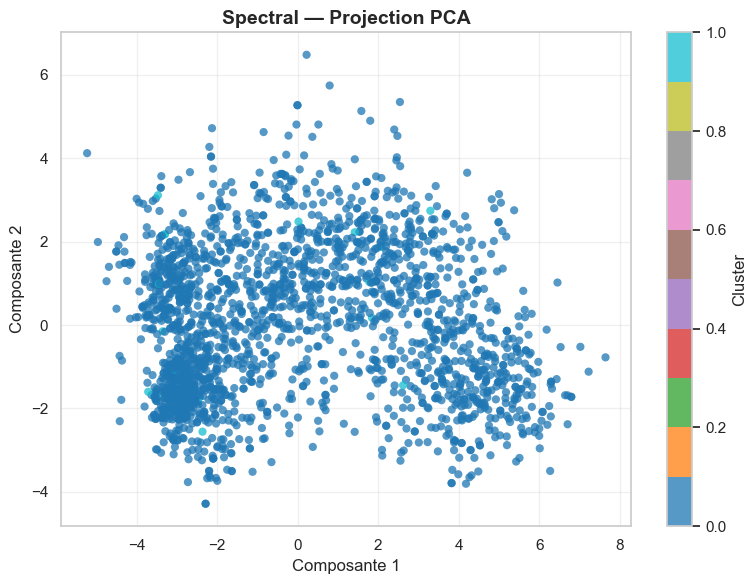

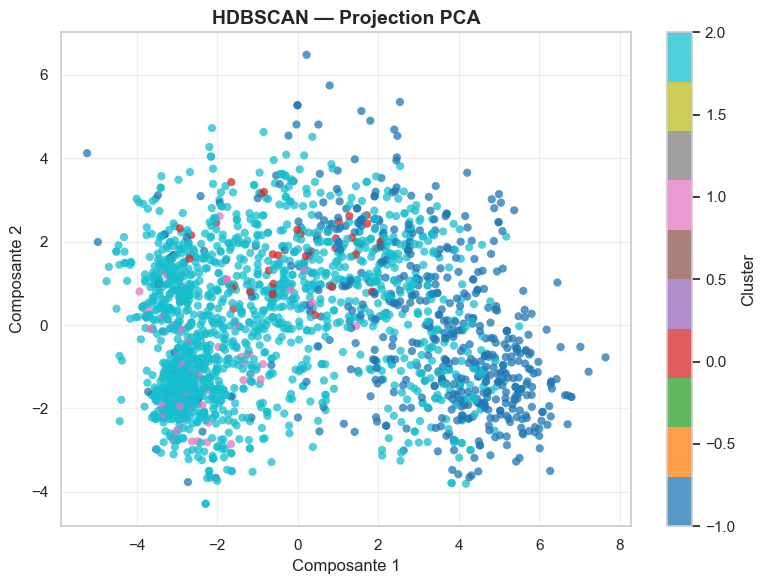

In [156]:
for name, labels in cluster_results.items():
    plot_clusters(
        X_pca,
        labels,
        f"{name} — Projection PCA"
    )

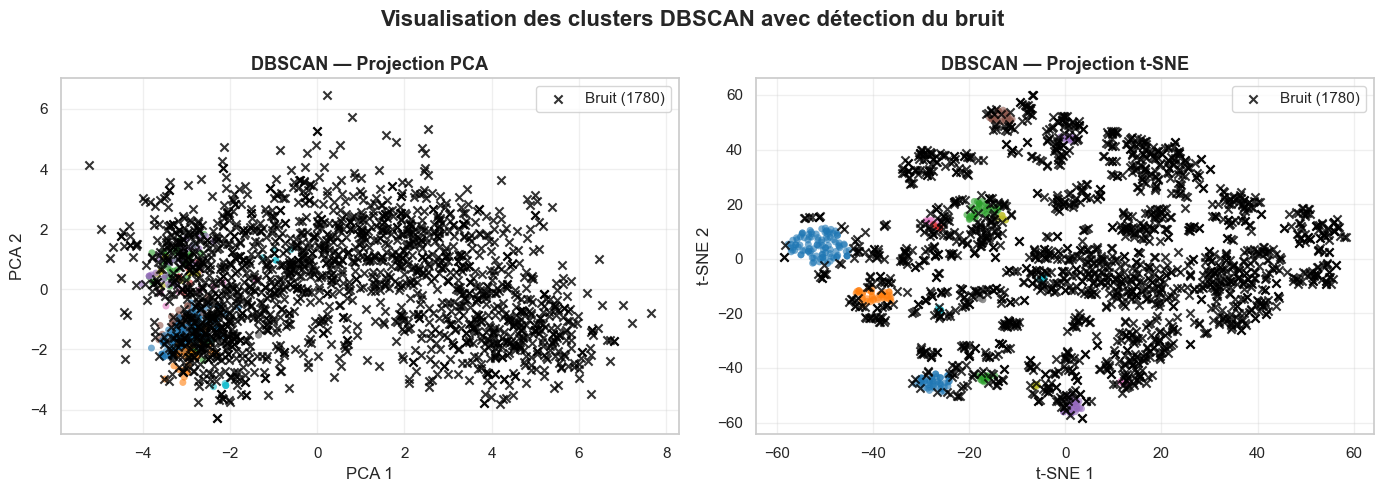

In [157]:
# Visualisation DBSCAN avec bruit sur PCA et t-SNE
noise_mask = labels_dbscan == -1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, coords, title in zip(axes, [X_pca, X_tsne], ["PCA", "t-SNE"]):

    ax.scatter(
        coords[~noise_mask, 0],
        coords[~noise_mask, 1],
        c=labels_dbscan[~noise_mask],
        cmap="tab10",
        alpha=0.6,
        s=25,
        edgecolors="none"
    )

    ax.scatter(
        coords[noise_mask, 0],
        coords[noise_mask, 1],
        c="black",
        marker="x",
        s=35,
        alpha=0.8,
        label=f"Bruit ({n_noise_db})"
    )

    ax.set_title(f"DBSCAN — Projection {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{title} 1")
    ax.set_ylabel(f"{title} 2")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(
    "Visualisation des clusters DBSCAN avec détection du bruit",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("Visualisation_DBSCAN.png", dpi=300)
plt.show()


 Classification hiérarchique : dendrogramme

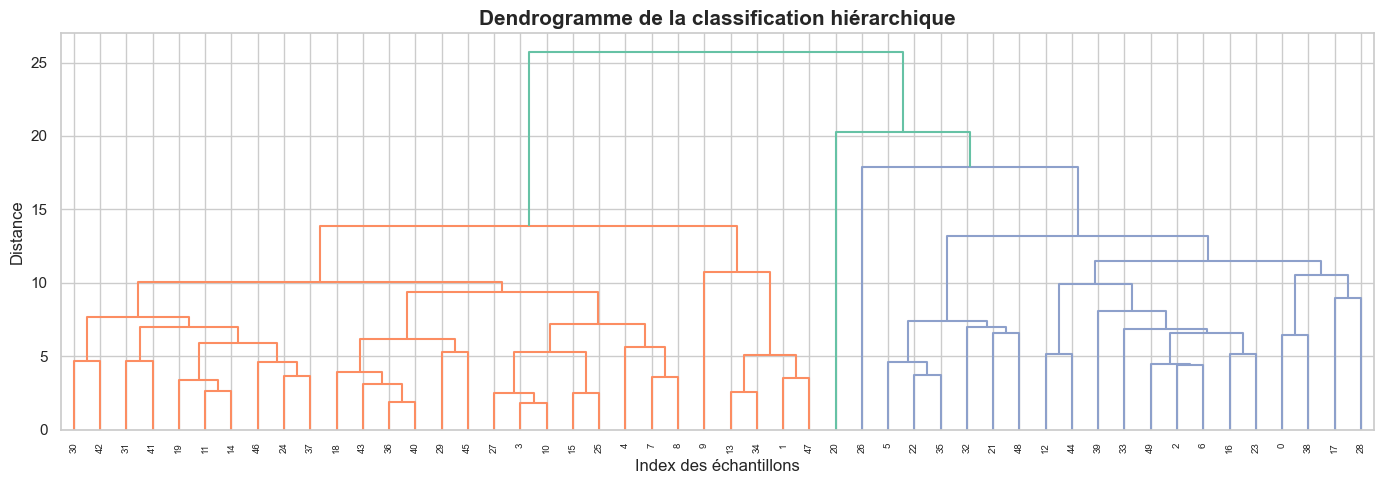

In [158]:
Z = linkage(X_clean[:50], method="ward")

plt.figure(figsize=(14, 5))
dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=0.7 * max(Z[:, 2])
)

plt.title("Dendrogramme de la classification hiérarchique", fontweight="bold")
plt.xlabel("Index des échantillons")
plt.ylabel("Distance")
plt.savefig("Courbe_k_distance.png", dpi=300)
plt.tight_layout()
plt.show()

 Optimisation de GMM avec AIC et BIC

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

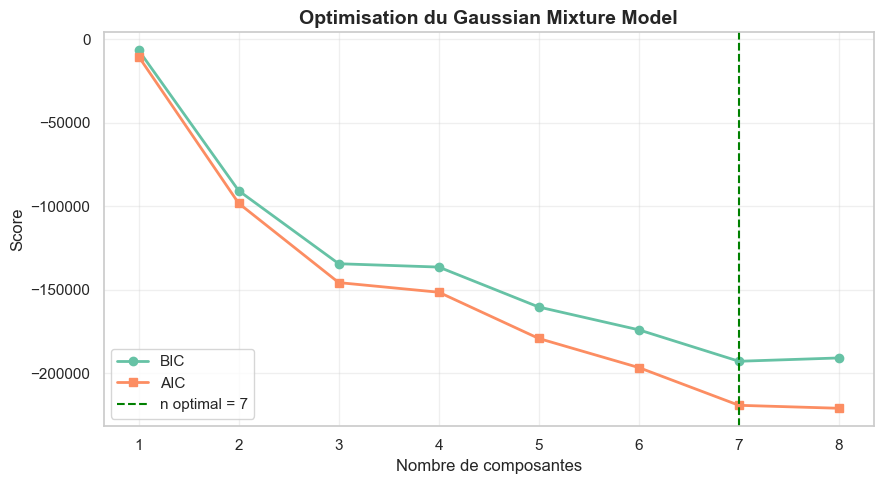

Meilleur nombre de composantes selon le BIC : 7


In [159]:
n_comp_range = range(1, 9)

bics = []
aics = []

for n in n_comp_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42,
        n_init=3
    )

    gmm.fit(X_clean)

    bics.append(gmm.bic(X_clean))
    aics.append(gmm.aic(X_clean))

best_n = list(n_comp_range)[np.argmin(bics)]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(list(n_comp_range), bics, marker="o", linewidth=2, label="BIC")
ax.plot(list(n_comp_range), aics, marker="s", linewidth=2, label="AIC")

ax.axvline(
    best_n,
    color="green",
    linestyle="--",
    label=f"n optimal = {best_n}"
)

ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Score")
ax.set_title("Optimisation du Gaussian Mixture Model", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Optimisation_Gaussian_Mixture_Model.png", dpi=300)
plt.show()

print(f"Meilleur nombre de composantes selon le BIC : {best_n}")

## 13. Analyse des centroïdes de K-Means

Total_Spent            1.603542
Num_Total_Purchases    1.532086
NumStorePurchases      1.494482
Income                 1.490817
NumCatalogPurchases    1.470916
Spent_Per_Purchase     1.446367
MntWines               1.398134
MntMeatProducts        1.307079
Kidhome                1.228472
MntFishProducts        1.176835
dtype: float64

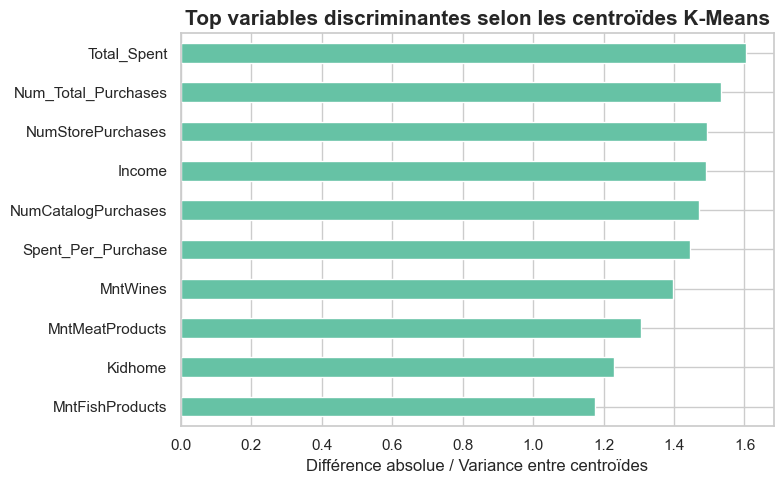

In [160]:
# Centroïdes en espace standardisé
centroids_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=feature_names
)

# Variables qui différencient le plus les clusters
if km_final.n_clusters == 2:
    diff = (centroids_df.iloc[0] - centroids_df.iloc[1]).abs().sort_values(ascending=False)
else:
    diff = centroids_df.var(axis=0).sort_values(ascending=False)

top_features = diff.head(10)

display(top_features)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind="barh")
plt.title("Top variables discriminantes selon les centroïdes K-Means", fontweight="bold")
plt.xlabel("Différence absolue / Variance entre centroïdes")
plt.savefig("Top_Variables_Discriminantes.png", dpi=300)
plt.tight_layout()
plt.show()

 Importance des variables dans PCA

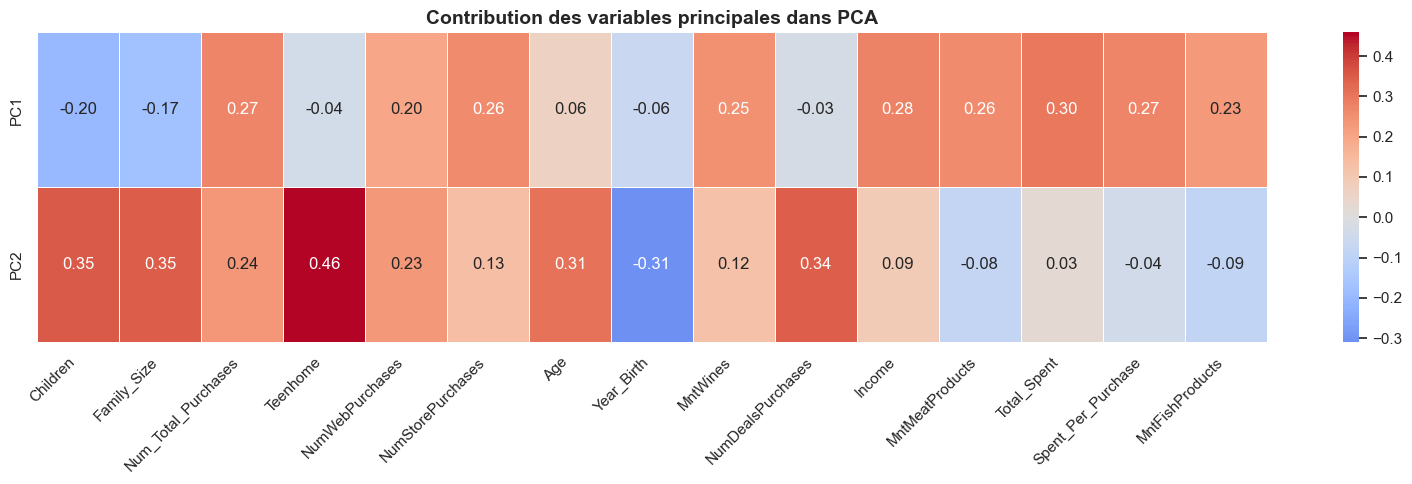

In [162]:
pca_importance = pd.DataFrame(
    pca_2d.components_,
    columns=feature_names,
    index=["PC1", "PC2"]
)

top_pca_features = (
    pca_importance
    .abs()
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    pca_importance[top_pca_features],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Contribution des variables principales dans PCA", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Contribution_Variables_PCA.png", dpi=300)
plt.show()

 Évaluation comparative des modèles

In [163]:
def eval_clustering(labels, X, model_name, y_true=None):
    labels = np.array(labels)

    valid_mask = labels != -1

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    if n_clusters < 2 or np.sum(valid_mask) < 2:
        return {
            "Modèle": model_name,
            "N_clusters": n_clusters,
            "N_bruit": n_noise,
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "ARI": np.nan,
            "NMI": np.nan
        }

    sil = silhouette_score(X[valid_mask], labels[valid_mask])
    dbi = davies_bouldin_score(X[valid_mask], labels[valid_mask])
    ch = calinski_harabasz_score(X[valid_mask], labels[valid_mask])

    ari = np.nan
    nmi = np.nan

    if y_true is not None and len(y_true) == len(labels):
        y_true = np.array(y_true)
        ari = adjusted_rand_score(y_true[valid_mask], labels[valid_mask])
        nmi = normalized_mutual_info_score(y_true[valid_mask], labels[valid_mask])

    return {
        "Modèle": model_name,
        "N_clusters": n_clusters,
        "N_bruit": n_noise,
        "Silhouette": round(sil, 4),
        "Davies-Bouldin": round(dbi, 4),
        "Calinski-Harabasz": round(ch, 2),
        "ARI": round(ari, 4) if not np.isnan(ari) else np.nan,
        "NMI": round(nmi, 4) if not np.isnan(nmi) else np.nan
    }

In [164]:
results = [
    eval_clustering(labels, X_clean, name)
    for name, labels in cluster_results.items()
]

df_results = pd.DataFrame(results).set_index("Modèle")
df_results = df_results.round(4)

print("=" * 80)
print("TABLEAU COMPARATIF DES ALGORITHMES DE CLUSTERING")
print("=" * 80)

display(df_results)

best_model = df_results["Silhouette"].idxmax()

print(f"Meilleur modèle selon le Silhouette Score : {best_model}")

print("\nInterprétation des métriques :")
print("• Silhouette Score       : plus élevé = meilleur clustering")
print("• Davies-Bouldin Index   : plus faible = meilleure séparation")
print("• Calinski-Harabasz      : plus élevé = clusters plus compacts")
print("• ARI / NMI              : utilisés seulement si des labels réels existent")

TABLEAU COMPARATIF DES ALGORITHMES DE CLUSTERING


,N_clusters,N_bruit,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
Modèle,,,,,,,
K-Means,2,0,0.2303,1.7995,601.57,NaN,NaN
DBSCAN,16,1780,0.3352,0.9866,52.21,NaN,NaN
Agglomerative,2,0,0.2166,1.8913,478.16,NaN,NaN
GMM,2,0,0.2300,1.9286,489.35,NaN,NaN
Spectral,2,0,0.4220,0.9186,68.16,NaN,NaN
HDBSCAN,3,522,0.1069,1.7330,51.44,NaN,NaN


Meilleur modèle selon le Silhouette Score : Spectral

Interprétation des métriques :
• Silhouette Score       : plus élevé = meilleur clustering
• Davies-Bouldin Index   : plus faible = meilleure séparation
• Calinski-Harabasz      : plus élevé = clusters plus compacts
• ARI / NMI              : utilisés seulement si des labels réels existent


## 16. Robustesse avec bruit

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Silhouette Score avec bruit : 0.2198


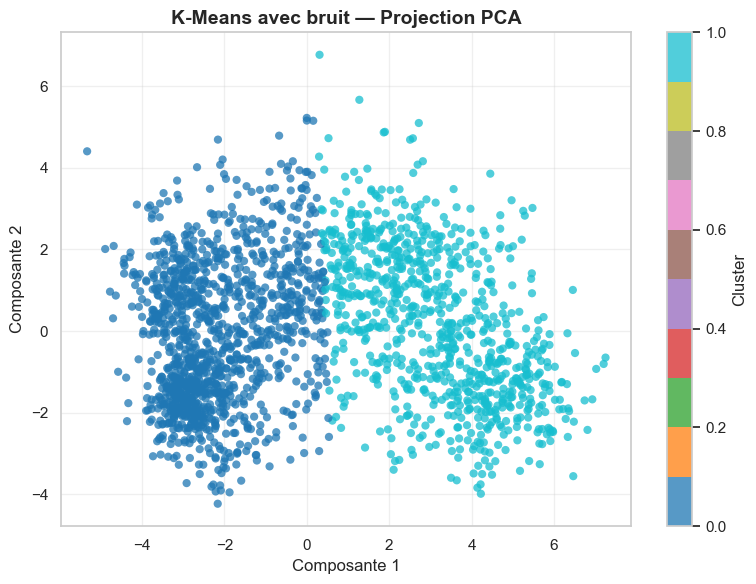

<Figure size 900x600 with 0 Axes>

In [166]:
np.random.seed(42)

noise = np.random.normal(
    loc=0,
    scale=0.2,
    size=X_clean.shape
)

X_noisy = X_clean + noise

kmeans_noise = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels_noise = kmeans_noise.fit_predict(X_noisy)

score_noise = silhouette_score(X_noisy, labels_noise)

print("Silhouette Score avec bruit :", round(score_noise, 4))

X_noisy_pca = PCA(n_components=2, random_state=42).fit_transform(X_noisy)

plot_clusters(
    X_noisy_pca,
    labels_noise,
    "K-Means avec bruit — Projection PCA"
)
plt.savefig("K_Means_avec_bruit_PCA.png", dpi=300)


## 17. Stabilité des clusters

In [167]:
stability_scores = []

for seed in range(10):
    model = KMeans(
        n_clusters=best_k,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_clean)
    score = silhouette_score(X_clean, labels)
    stability_scores.append(score)

print("Scores de stabilité :", np.round(stability_scores, 4))
print("Moyenne :", round(np.mean(stability_scores), 4))
print("Écart-type :", round(np.std(stability_scores), 4))

c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Scores de stabilité : [0.2303 0.2302 0.2302 0.2302 0.2302 0.2303 0.2303 0.2303 0.2303 0.2303]
Moyenne : 0.2302
Écart-type : 0.0
